# How NFL Win Probability Works — and Building Our Own

**Goal:** given the game situation right now (score, clock, down, distance, field position, timeouts, and who's the better team), estimate the probability the team with the ball wins.

We'll build up in layers, and each one teaches something:

| Part | Model | The idea it teaches |
|---|---|---|
| 1 | Just look at history | WP is "how often did teams in this spot win?" |
| 2 | Stern's random-walk formula | Why leads get safer as the clock runs down |
| 3 | Logistic regression | Turning a situation into a probability, and why *feature design* matters |
| 4 | XGBoost | Letting the model find the interactions itself (this is what nflfastR does) |
| 5 | Replay a real game | Seeing the swings, play by play |
| 6 | What-if tool | Ask your own questions |

Throughout, **everything is from the perspective of the team with the ball** (`posteam`).

> Run cells top to bottom with **Shift+Enter**. The first data download takes ~30–60 seconds.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, log_loss
import xgboost as xgb
import nflreadpy as nfl

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 140, "display.max_colwidth", 90)

## 0. Get the data

[nflverse](https://github.com/nflverse) publishes every NFL play since 1999, free. We'll use **2006–2025** (about 950k plays). Each row is one play, with the situation *before* the snap and, crucially, the final result of the game, which is our answer key.

In [2]:
SEASONS = list(range(2006, 2026))
COLS = [
    "season", "season_type", "week", "game_id", "play_id", "posteam", "defteam", "home_team", "away_team",
    "qtr", "game_seconds_remaining", "half_seconds_remaining", "down", "ydstogo", "yardline_100",
    "score_differential", "posteam_timeouts_remaining", "defteam_timeouts_remaining",
    "spread_line", "result", "ep", "vegas_wp", "desc",
]
raw = nfl.load_pbp(SEASONS).select(COLS).to_pandas()
print(f"{len(raw):,} rows, {raw.game_id.nunique():,} games")

955,338 rows, 5,431 games


### Shaping the data

A few decisions (each is a simplification worth knowing about):

- **Keep only snaps with a down** (runs, passes, punts, field goals). Kickoffs and extra points are a different situation.
- **Regulation only (quarters 1–4).** Overtime has its own rules; we'll handle it separately later.
- **Drop tied games** (very rare) so every game has a winner.
- **`label`** = 1 if the team with the ball went on to win.
- **`posteam_spread`**: the Vegas line from the offense's point of view. In this data `spread_line = +7` means the *home* team was favored by 7, so we flip the sign when the away team has the ball.
- **`receive_2h_ko`**: does this team get the ball to start the 2nd half? Down 3 at halftime is better if you're about to get the ball.

In [3]:
df = raw[raw.posteam.notna() & raw.down.notna() & raw.qtr.le(4) & raw.result.ne(0)
         & raw.game_seconds_remaining.notna() & raw.spread_line.notna()].copy()

is_home = df.posteam == df.home_team
df["home"] = is_home.astype(int)
df["label"] = np.where(is_home, df.result > 0, df.result < 0).astype(int)
df["posteam_spread"] = np.where(is_home, df.spread_line, -df.spread_line)

# whoever has the ball on the game's first snap received the opening kickoff;
# the other team receives the 2nd-half kickoff
opening_receiver = df.sort_values(["game_id", "play_id"]).groupby("game_id").posteam.first()
df["receive_2h_ko"] = ((df.qtr <= 2) & (df.posteam != df.game_id.map(opening_receiver))).astype(int)

df[["game_id", "qtr", "game_seconds_remaining", "posteam", "score_differential",
    "down", "ydstogo", "yardline_100", "posteam_spread", "label"]].head(8)

,game_id,qtr,game_seconds_remaining,posteam,score_differential,down,ydstogo,yardline_100,posteam_spread,label
2,2006_01_ATL_CAR,1.0,3594.0,ATL,0.0,1.0,10.0,67.0,-4.5,1
3,2006_01_ATL_CAR,1.0,3558.0,ATL,0.0,2.0,5.0,62.0,-4.5,1
4,2006_01_ATL_CAR,1.0,3513.0,ATL,0.0,3.0,6.0,63.0,-4.5,1
5,2006_01_ATL_CAR,1.0,3478.0,ATL,0.0,1.0,10.0,53.0,-4.5,1
6,2006_01_ATL_CAR,1.0,3471.0,ATL,0.0,1.0,10.0,38.0,-4.5,1
7,2006_01_ATL_CAR,1.0,3437.0,ATL,0.0,2.0,5.0,33.0,-4.5,1
8,2006_01_ATL_CAR,1.0,3413.0,ATL,0.0,1.0,10.0,27.0,-4.5,1
9,2006_01_ATL_CAR,1.0,3408.0,ATL,0.0,2.0,10.0,27.0,-4.5,1


### Train / test split, done properly

Plays within a game are heavily linked (the same game, the same outcome). If plays from one game ended up in both training and testing, we'd be grading the model on games it has already seen. So we **split by season**:

- **Train:** 2006–2022 · **Validate:** 2023 (for tuning) · **Test:** 2024–2025 (never touched until the final grade)

In [4]:
train = df[df.season <= 2022]
valid = df[df.season == 2023]
test  = df[df.season >= 2024]
for name, d in [("train", train), ("valid", valid), ("test", test)]:
    print(f"{name:5s}: {len(d):>8,} plays  {d.game_id.nunique():>5,} games")

train:  674,519 plays  4,563 games
valid:   41,706 plays    285 games
test :   81,654 plays    569 games


## 1. The simplest possible "model": just look at history

Win probability is, at heart, a **lookup**: *of all the teams that were in this situation, what fraction won?*

Below: how often the team with the ball won, by score margin, at different points in the game. Notice how the curve **gets steeper as time runs out**: a 7-point lead is worth a little in the 1st quarter and nearly everything at the end.

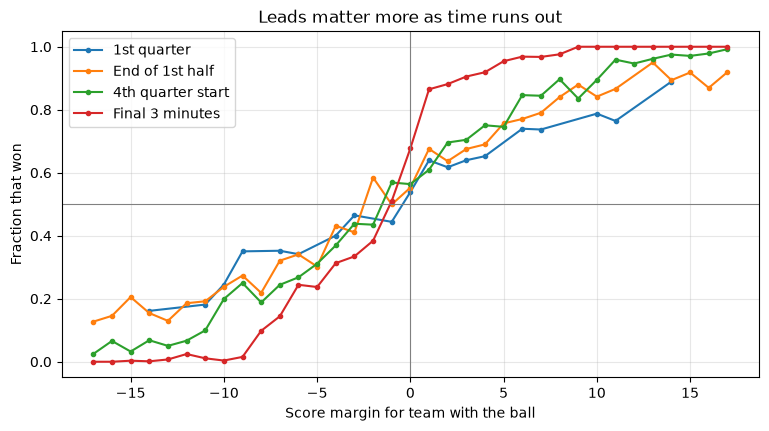

In [5]:
phases = {
    "1st quarter":          train.game_seconds_remaining > 2700,
    "End of 1st half": train.game_seconds_remaining.between(1800, 2100),
    "4th quarter start":    train.game_seconds_remaining.between(600, 900),
    "Final 3 minutes":      train.game_seconds_remaining < 180,
}
fig, ax = plt.subplots()
for label, mask in phases.items():
    g = train[mask & train.score_differential.between(-17, 17)].groupby("score_differential").label.agg(["mean", "size"])
    g = g[g["size"] >= 200]
    ax.plot(g.index, g["mean"], marker="o", ms=3, label=label)
ax.axhline(0.5, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.set(xlabel="Score margin for team with the ball", ylabel="Fraction that won", title="Leads matter more as time runs out")
ax.legend(); plt.show()

**Why we can't stop here:** once you add down, distance, yard line, timeouts, *and* the spread, there are millions of combinations, and most have few or no historical examples. ("Down 4, 1:37 left, 3rd & 7 at the opponent's 33, 1 timeout, 3-point underdog" might have happened twice.) A **model** fills in the gaps by learning smooth patterns.

## 2. Stern's random-walk model (1994)

Hal Stern noticed that NFL scoring over the rest of a game behaves roughly like a **random walk**:

- Over a full game, the final margin ends up close to the Vegas spread on average, with a standard deviation of **σ ≈ 13–14 points**.
- If a fraction **τ** of the game remains, the remaining scoring has mean **spread × τ** and standard deviation **σ√τ**.

So the team with the ball wins if its current lead plus the remaining scoring stays above zero:

$$P(\text{win}) = \Phi\left(\frac{\text{lead} + \text{spread}\cdot\tau}{\sigma\sqrt{\tau}}\right)$$

where Φ is the standard normal curve (it turns a z-score into a probability).

**The key insight:** as τ → 0, the denominator σ√τ shrinks, so the *same* lead becomes a larger and larger z-score. That's the steepening curve from Part 1, in one formula.

First, let's measure σ from our own data:

In [6]:
games = train.groupby("game_id").agg(result=("result", "first"), spread=("spread_line", "first"))
SIGMA = (games.result - games.spread).std()
print(f"σ (std of final margin vs. Vegas spread) = {SIGMA:.2f} points  over {len(games):,} games")
print(f"Vegas picks the right winner {np.mean(np.sign(games.result) == np.sign(games.spread)):.1%} of the time (excluding pick'ems)")

σ (std of final margin vs. Vegas spread) = 13.28 points  over 4,563 games
Vegas picks the right winner 66.0% of the time (excluding pick'ems)


In [7]:
def stern_wp(lead, seconds_left, spread, sigma=SIGMA):
    tau = np.clip(np.asarray(seconds_left, float) / 3600, 1e-4, 1)
    return norm.cdf((lead + spread * tau) / (sigma * np.sqrt(tau)))

# Quick sanity checks
for lead, secs, spread in [(0, 3600, 0), (0, 3600, 7), (7, 3600, 0), (7, 900, 0), (7, 120, 0), (-3, 120, 0)]:
    print(f"lead {lead:+3d}, {secs/60:4.0f} min left, spread {spread:+d}:  WP = {stern_wp(lead, secs, spread):.1%}")

lead  +0,   60 min left, spread +0:  WP = 50.0%
lead  +0,   60 min left, spread +7:  WP = 70.1%
lead  +7,   60 min left, spread +0:  WP = 70.1%
lead  +7,   15 min left, spread +0:  WP = 85.4%
lead  +7,    2 min left, spread +0:  WP = 99.8%
lead  -3,    2 min left, spread +0:  WP = 10.8%


### Upgrade: account for field position

Plain Stern ignores *where the ball is*. Having 1st & goal at the 2 is worth almost a touchdown. **Expected Points (EP)** captures that: the average number of points the next score is worth from this down, distance and yard line. (EP is its own model; here we borrow nflfastR's `ep` column.) We simply add it to the lead:

$$P(\text{win}) = \Phi\left(\frac{\text{lead} + \text{EP} + \text{spread}\cdot\tau}{\sigma\sqrt{\tau}}\right)$$

In [8]:
def stern_ep_wp(d, sigma=SIGMA):
    return stern_wp(d.score_differential + d.ep.fillna(0), d.game_seconds_remaining, d.posteam_spread, sigma)

### How do we grade a probability?

A probability can't be "right" or "wrong" on one play, so we grade over many plays:

- **Calibration:** when the model says 70%, do those teams win ~70% of the time? Plot predicted vs. actual; a perfect model is on the diagonal.
- **Brier score:** average of (prediction − outcome)². Lower is better. Always guessing 50% scores 0.25.
- **Log loss:** like Brier, but punishes confident wrong answers much harder. Lower is better. Always guessing 50% scores 0.693.
- **Brier, final 5 min:** the same score, but only on the last 5 minutes of games. Early-game plays are mostly near 50/50 and flood the overall average, while late-game situations are where WP is most interesting and hardest to get right.

All three are **lower is better**, like golf. The **"Always 50%"** row is the no-knowledge baseline: it's off by exactly 0.5 on every play, so it always scores 0.25 Brier. A useful model has to land clearly below it.

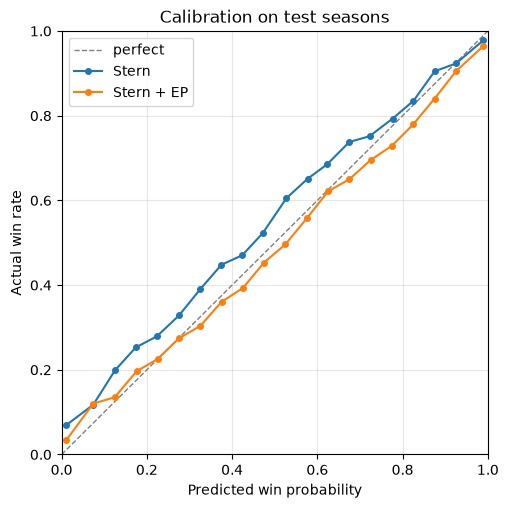

,Brier (lower is better),Log loss (lower is better),"Brier, final 5 min (lower is better)"
Stern,0.1556,0.4872,0.1046
Stern + EP,0.1510,0.4604,0.0847
Always 50%,0.2500,0.6931,0.2500


In [9]:
scoreboard = {}

def grade(name, d, p):
    p = np.asarray(p)
    late = (d.game_seconds_remaining < 300).values
    scoreboard[name] = {"Brier (lower is better)": brier_score_loss(d.label, p), "Log loss (lower is better)": log_loss(d.label, np.clip(p, 1e-6, 1 - 1e-6)),
                        "Brier, final 5 min (lower is better)": brier_score_loss(d.label[late], p[late])}
    return pd.DataFrame(scoreboard).T.round(4)

def calibration_plot(d, preds: dict, bins=20, title="Calibration on test seasons"):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.plot([0, 1], [0, 1], color="gray", ls="--", lw=1, label="perfect")
    for name, p in preds.items():
        b = pd.cut(p, np.linspace(0, 1, bins + 1), include_lowest=True)
        g = pd.DataFrame({"p": p, "y": d.label.values}).groupby(b, observed=True).mean()
        ax.plot(g.p, g.y, marker="o", ms=4, label=name)
    ax.set(xlabel="Predicted win probability", ylabel="Actual win rate", title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend(); plt.show()

test_preds = {
    "Stern": stern_wp(test.score_differential, test.game_seconds_remaining, test.posteam_spread),
    "Stern + EP": stern_ep_wp(test),
}
for k, p in test_preds.items():
    grade(k, test, p)
calibration_plot(test, test_preds)
grade("Always 50%", test, np.full(len(test), 0.5))

A two-parameter formula from 1994 gets surprisingly close. Adding field position helps noticeably. Its weaknesses: it knows nothing about timeouts or the end-of-half clock, and it assumes scoring flows smoothly when it really comes in 3s and 7s.

## 3. Logistic regression: learning the formula from data

Logistic regression is the workhorse for "predict a yes/no outcome". It computes a weighted sum of features and squashes it into 0–1:

$$P(\text{win}) = \frac{1}{1 + e^{-(w_1 x_1 + w_2 x_2 + \dots + b)}}$$

The weights `w` are learned from history. We'll try it twice to show why **feature design** matters.

**Watch the "final 5 min" column.**

### 3a. Naive: throw in the raw numbers

In [10]:
NAIVE = ["score_differential", "game_seconds_remaining", "posteam_spread", "down", "ydstogo", "yardline_100",
         "posteam_timeouts_remaining", "defteam_timeouts_remaining", "home", "receive_2h_ko"]
lr_naive = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(train[NAIVE], train.label)
test_preds["LogReg (naive)"] = lr_naive.predict_proba(test[NAIVE])[:, 1]
grade("LogReg (naive)", test, test_preds["LogReg (naive)"])

,Brier (lower is better),Log loss (lower is better),"Brier, final 5 min (lower is better)"
Stern,0.1556,0.4872,0.1046
Stern + EP,0.1510,0.4604,0.0847
Always 50%,0.2500,0.6931,0.2500
LogReg (naive),0.1514,0.4580,0.1002


Overall it beats Stern (it knows about field position), but it's **weaker than Stern + EP in the final 5 minutes**. Why? A plain weighted sum gives a 7-point lead the **same** value whether it's the 1st quarter or the final minute. It cannot represent "leads matter more late," and late game is exactly where that matters.

### 3b. Engineered: add Stern's z-score as a feature

We keep all the raw features and add one more: Stern's z-score, which already combines lead, spread and time in the right shape. The model then learns how much field position, timeouts and so on adjust it.

In [11]:
def add_features(d):
    d = d.copy()
    tau = np.clip(d.game_seconds_remaining / 3600, 1e-4, 1)
    d["stern_z"] = ((d.score_differential + d.posteam_spread * tau) / (SIGMA * np.sqrt(tau))).clip(-8, 8)
    # nflfastR-style time interactions (used by the XGBoost model below)
    elapsed = (3600 - d.game_seconds_remaining) / 3600
    d["spread_time"] = d.posteam_spread * np.exp(-4 * elapsed)
    d["diff_time_ratio"] = d.score_differential / np.exp(-4 * elapsed)
    return d

train, valid, test = add_features(train), add_features(valid), add_features(test)

ENGINEERED = NAIVE + ["stern_z"]
lr_eng = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(train[ENGINEERED], train.label)
test_preds["LogReg (engineered)"] = lr_eng.predict_proba(test[ENGINEERED])[:, 1]

coefs = pd.Series(lr_eng[-1].coef_[0], index=ENGINEERED).sort_values(key=abs, ascending=False)
print("Learned weights (on standardized features; bigger = more influence):\n", coefs.round(3).to_string())
grade("LogReg (engineered)", test, test_preds["LogReg (engineered)"])

Learned weights (on standardized features; bigger = more influence):
 stern_z                       1.558
score_differential            0.783
posteam_spread                0.536
yardline_100                 -0.218
game_seconds_remaining       -0.128
down                         -0.108
home                         -0.092
receive_2h_ko                 0.086
ydstogo                      -0.043
defteam_timeouts_remaining   -0.013
posteam_timeouts_remaining   -0.007


,Brier (lower is better),Log loss (lower is better),"Brier, final 5 min (lower is better)"
Stern,0.1556,0.4872,0.1046
Stern + EP,0.1510,0.4604,0.0847
Always 50%,0.2500,0.6931,0.2500
LogReg (naive),0.1514,0.4580,0.1002
LogReg (engineered),0.1484,0.4486,0.0867


One extra column gives a big improvement, especially late in games. `stern_z` gets by far the largest weight. `yardline_100` is negative (farther from the end zone is worse).

**The lesson:** a simple model with one well-chosen feature can beat a simple model with lots of raw ones. Much of practical modeling is *feature design*: putting what you know about the problem into the inputs.

## 4. XGBoost: let the model find the interactions

Gradient-boosted trees build hundreds of small decision trees, each correcting the previous ones' mistakes. Trees naturally learn interactions like *"3rd & long matters a lot with 1:00 left down 4, and barely at all in the 1st quarter."* This is the approach **nflfastR's** public WP model uses, and our feature set mirrors theirs.

We also add **monotone constraints**, common-sense rules the model may not break: more points is never worse, being a bigger favorite is never worse, more of *your* timeouts is never worse. This prevents odd artifacts in rare situations.

In [12]:
FEATURES = ["score_differential", "diff_time_ratio", "posteam_spread", "spread_time",
            "game_seconds_remaining", "half_seconds_remaining", "down", "ydstogo", "yardline_100",
            "posteam_timeouts_remaining", "defteam_timeouts_remaining", "home", "receive_2h_ko"]
MONOTONE = {"score_differential": 1, "diff_time_ratio": 1, "posteam_spread": 1, "spread_time": 1,
            "posteam_timeouts_remaining": 1, "defteam_timeouts_remaining": -1}

model = xgb.XGBClassifier(
    n_estimators=3000, learning_rate=0.03, max_depth=5, min_child_weight=50,
    subsample=0.8, colsample_bytree=0.8, tree_method="hist",
    monotone_constraints=tuple(MONOTONE.get(f, 0) for f in FEATURES),
    eval_metric="logloss", early_stopping_rounds=100,
)
model.fit(train[FEATURES], train.label, eval_set=[(valid[FEATURES], valid.label)], verbose=False)
print(f"Best number of trees (picked on 2023 validation season): {model.best_iteration}")

test_preds["XGBoost"] = model.predict_proba(test[FEATURES])[:, 1]
grade("XGBoost", test, test_preds["XGBoost"])

Best number of trees (picked on 2023 validation season): 382


,Brier (lower is better),Log loss (lower is better),"Brier, final 5 min (lower is better)"
Stern,0.1556,0.4872,0.1046
Stern + EP,0.1510,0.4604,0.0847
Always 50%,0.2500,0.6931,0.2500
LogReg (naive),0.1514,0.4580,0.1002
LogReg (engineered),0.1484,0.4486,0.0867
XGBoost,0.1486,0.4484,0.0822


Notice that XGBoost lands about **level with the engineered logistic regression overall**, because our hand-built Stern feature already captured most of what the trees discover on their own. Where XGBoost pulls ahead is the **final 5 minutes**, where timeouts, field position and the clock interact in ways a weighted sum can't express (see the what-if examples in Part 6, where the two disagree).

### Final grade: all models, plus the nflfastR benchmark

nflfastR's `vegas_wp` is a well-respected public model, so it makes a good reference point. (Caveat: we don't know exactly which seasons it was trained on, so this comparison is rough.)

,Brier (lower is better),Log loss (lower is better),"Brier, final 5 min (lower is better)"
nflfastR vegas_wp,0.1475,0.4457,0.0798
LogReg (engineered),0.1484,0.4486,0.0867
XGBoost,0.1486,0.4484,0.0822
Stern + EP,0.1510,0.4604,0.0847
LogReg (naive),0.1514,0.4580,0.1002
Stern,0.1556,0.4872,0.1046


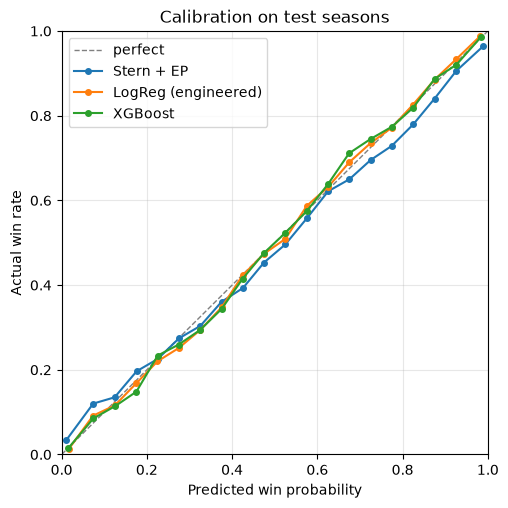

In [13]:
has_bench = test.vegas_wp.notna()
bench = test[has_bench]
rows = {}
for name, p in {**test_preds, "nflfastR vegas_wp": test.vegas_wp.values}.items():
    p = np.asarray(p)[has_bench.values]
    late = (bench.game_seconds_remaining < 300).values
    rows[name] = {"Brier (lower is better)": brier_score_loss(bench.label, p), "Log loss (lower is better)": log_loss(bench.label, np.clip(p, 1e-6, 1 - 1e-6)),
                  "Brier, final 5 min (lower is better)": brier_score_loss(bench.label[late], p[late])}
display(pd.DataFrame(rows).T.sort_values("Brier (lower is better)").round(4))

calibration_plot(test, {k: test_preds[k] for k in ["Stern + EP", "LogReg (engineered)", "XGBoost"]})

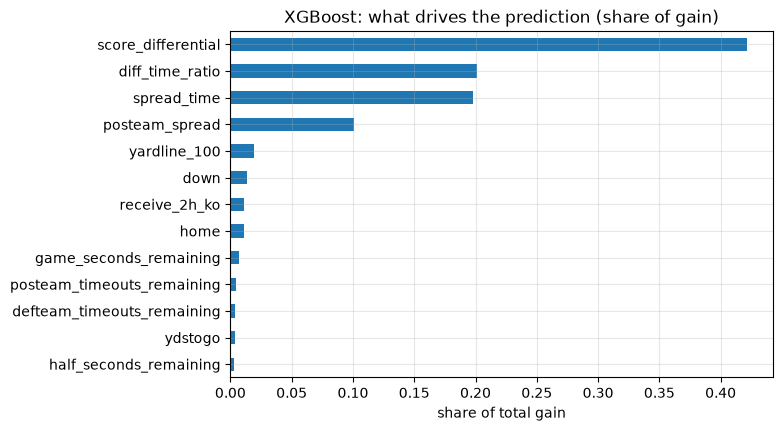

In [14]:
imp = pd.Series(model.get_booster().get_score(importance_type="gain")).reindex(FEATURES).fillna(0).sort_values()
ax = (imp / imp.sum()).plot.barh(figsize=(7, 4.5), title="XGBoost: what drives the prediction (share of gain)")
ax.set_xlabel("share of total gain"); plt.show()

## 5. Replay a real game: Super Bowl LIX (Chiefs vs. Eagles, Feb 2025)

This game is in our **test** set, so the model never saw it. We convert every prediction to **"Eagles win probability"** and compare our curve to nflfastR's.

*(Note: the Super Bowl is at a neutral site, but the data still lists a "home" team, which gives it a slight home-field boost here. A small known flaw.)*

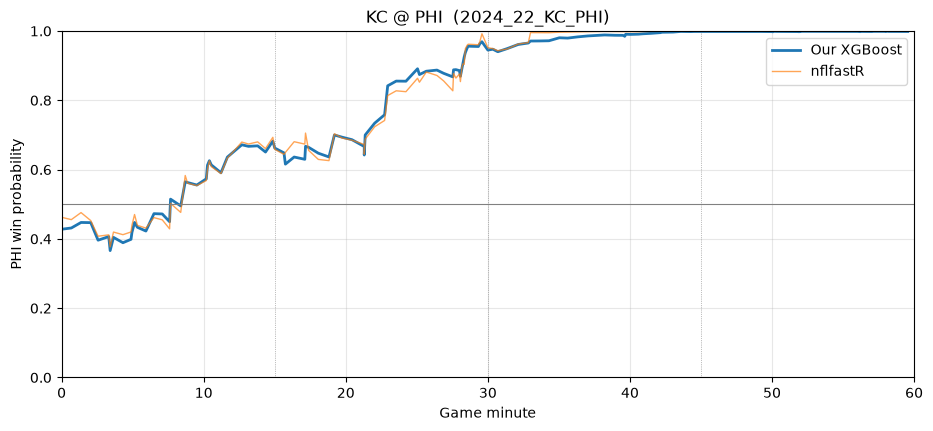

,qtr,posteam,desc,swing
906448,2.0,KC,(7:16) (Shotgun) 15-P.Mahomes pass short right intended for 8-D.Hopkins INTERCEPTED by...,8.3 pts
906411,1.0,PHI,"(6:37) (Shotgun) 1-J.Hurts pass deep right to 83-J.Dotson for 28 yards, TOUCHDOWN. The...",7.0 pts
906409,1.0,PHI,"(7:24) (No Huddle, Shotgun) 1-J.Hurts pass incomplete short right to 88-D.Goedert. PEN...",6.5 pts
906438,2.0,PHI,(11:11) (Shotgun) 1-J.Hurts pass deep right to 11-A.Brown pushed ob at KC 32 for 22 ya...,6.3 pts
906444,2.0,PHI,"(8:42) 4-J.Elliott 48 yard field goal is GOOD, Center-49-R.Lovato, Holder-10-B.Mann.",5.8 pts
906396,1.0,PHI,(12:57) (Shotgun) 1-J.Hurts pass short left to 26-S.Barkley to PHI 41 for -4 yards (32...,-5.1 pts


In [15]:
def game_chart(game_id, team=None):
    g = test[test.game_id == game_id].sort_values("play_id").copy()
    team = team or g.home_team.iloc[0]
    flip = g.posteam != team
    g["ours"] = np.where(flip, 1 - model.predict_proba(g[FEATURES])[:, 1], model.predict_proba(g[FEATURES])[:, 1])
    g["nflfastR"] = np.where(flip, 1 - g.vegas_wp, g.vegas_wp)
    minute = (3600 - g.game_seconds_remaining) / 60

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(minute, g.ours, lw=2, label="Our XGBoost")
    ax.plot(minute, g.nflfastR, lw=1, alpha=0.7, label="nflfastR")
    ax.axhline(0.5, color="gray", lw=0.8)
    for q in (15, 30, 45): ax.axvline(q, color="gray", lw=0.5, ls=":")
    ax.set(xlim=(0, 60), ylim=(0, 1), xlabel="Game minute", ylabel=f"{team} win probability",
           title=f"{g.away_team.iloc[0]} @ {g.home_team.iloc[0]}  ({game_id})")
    ax.legend(); plt.show()

    g["swing"] = g.ours.diff().shift(-1)  # how much the WP moved because of this play
    top = g.reindex(g.swing.abs().sort_values(ascending=False).index).head(6)
    return top.assign(swing=lambda t: (t.swing * 100).round(1).astype(str) + " pts")[["qtr", "posteam", "desc", "swing"]]

game_chart("2024_22_KC_PHI", team="PHI")

The table lists the **biggest swing plays** (in WP percentage points for the Eagles). These are the turnovers and big plays you'd expect.

Try another game. Game IDs look like `SEASON_WEEK_AWAY_HOME`:

In [16]:
# A few 2025 games to try (change the filter to find your team)
test[(test.season == 2025) & (test.home_team == "BUF")].groupby("game_id").first()[["away_team", "result"]].head(10)

,away_team,result
game_id,,
2025_01_BAL_BUF,BAL,1
2025_03_MIA_BUF,MIA,10
2025_04_NO_BUF,NO,12
2025_05_NE_BUF,NE,-3
2025_09_KC_BUF,KC,7
2025_11_TB_BUF,TB,12
2025_14_CIN_BUF,CIN,5
2025_17_PHI_BUF,PHI,-1
2025_18_NYJ_BUF,NYJ,27


## 6. What-if tool

Describe a situation and get a win probability from each model. **Edit the numbers and re-run.**

In [17]:
def win_prob(score_diff, seconds_left, down=1, ydstogo=10, yardline_100=75,
             pos_timeouts=3, def_timeouts=3, spread=0.0, home=1, receive_2h_ko=0):
    '''WP for the team with the ball. yardline_100 = yards from the OPPONENT's end zone (75 = own 25).
    spread = how many points this team was favored by before the game (negative = underdog).'''
    s = pd.DataFrame([dict(
        score_differential=score_diff, game_seconds_remaining=seconds_left,
        half_seconds_remaining=seconds_left - 1800 if seconds_left > 1800 else seconds_left,
        down=down, ydstogo=ydstogo, yardline_100=yardline_100, posteam_timeouts_remaining=pos_timeouts,
        defteam_timeouts_remaining=def_timeouts, posteam_spread=spread, home=home, receive_2h_ko=receive_2h_ko)])
    s = add_features(s)
    return {
        "Stern": round(float(stern_wp(score_diff, seconds_left, spread)), 3),
        "LogReg": round(float(lr_eng.predict_proba(s[ENGINEERED])[0, 1]), 3),
        "XGBoost": round(float(model.predict_proba(s[FEATURES])[0, 1]), 3),
    }

print("Down 4, 2:00 left, 1st & 10 at own 25, 1 timeout:   ", win_prob(-4, 120, 1, 10, 75, pos_timeouts=1))
print("Same, but 1st & 10 at the opponent's 20:            ", win_prob(-4, 120, 1, 10, 20, pos_timeouts=1))
print("Tied, opening kickoff, 7-point favorite at home:    ", win_prob(0, 3600, spread=7))

Down 4, 2:00 left, 1st & 10 at own 25, 1 timeout:    {'Stern': 0.05, 'LogReg': 0.23, 'XGBoost': 0.245}
Same, but 1st & 10 at the opponent's 20:             {'Stern': 0.05, 'LogReg': 0.327, 'XGBoost': 0.482}
Tied, opening kickoff, 7-point favorite at home:     {'Stern': 0.701, 'LogReg': 0.677, 'XGBoost': 0.746}


Look at the first two lines. Stern says **5%** in both cases because it ignores field position, and its smooth random walk doesn't know a single touchdown wins it. XGBoost says ~25% → ~48%, close to what real teams have done in those spots. Here the trees pull clearly ahead of the formula.

### Using WP to make decisions: go for it on 4th down?

This is what coaches and analytics departments actually use WP for. **Up 3, 4th & 1 at your own 34, 2:30 left.** Compare the WP after each choice:

- **Go for it:** convert (~70% on 4th & 1) → your 1st & 10 at your 35. Fail → *opponent's* ball at your 34, so we use 1 − (their WP).
- **Punt:** ~40-yard net → opponent gets 1st & 10 at their own 26.

In [18]:
def wp(**k): return win_prob(**k)["XGBoost"]

convert_rate = 0.70
t = 145  # seconds left after the play
go_success = wp(score_diff=3, seconds_left=t, down=1, ydstogo=10, yardline_100=65)
go_fail = 1 - wp(score_diff=-3, seconds_left=t, down=1, ydstogo=10, yardline_100=34)
go = convert_rate * go_success + (1 - convert_rate) * go_fail
punt = 1 - wp(score_diff=-3, seconds_left=t - 5, down=1, ydstogo=10, yardline_100=74)

print(f"Go for it: {go:.1%}   (convert → {go_success:.1%}, fail → {go_fail:.1%})")
print(f"Punt:      {punt:.1%}")
print(f"Break-even conversion rate: {(punt - go_fail) / (go_success - go_fail):.0%}")

Go for it: 72.0%   (convert → 79.3%, fail → 54.9%)
Punt:      70.8%
Break-even conversion rate: 65%


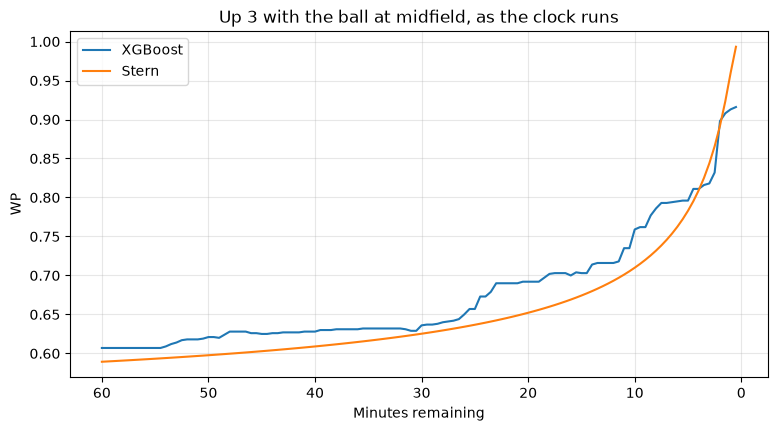

In [19]:
# How the value of a 3-point lead (ball at midfield, 1st & 10) changes as the clock runs
secs = np.arange(3600, 0, -30)
xgb_curve = [win_prob(3, s, 1, 10, 50)["XGBoost"] for s in secs]
plt.plot(secs / 60, xgb_curve, label="XGBoost")
plt.plot(secs / 60, stern_wp(3, secs, 0), label="Stern")
plt.gca().invert_xaxis()
plt.gca().set(xlabel="Minutes remaining", ylabel="WP", title="Up 3 with the ball at midfield, as the clock runs")
plt.legend(); plt.show()

## 7. Save the model for the live tracker

Next we'll build a live dashboard that reads the current game situation from ESPN and runs it through this model.

In [20]:
Path("models").mkdir(exist_ok=True)
model.save_model("models/wp_xgb.json")
Path("models/wp_meta.json").write_text(json.dumps({"features": FEATURES, "sigma": SIGMA}, indent=2))
print("Saved models/wp_xgb.json and models/wp_meta.json")

Saved models/wp_xgb.json and models/wp_meta.json


## Known limitations (good next experiments)

- **Overtime** isn't modeled; we only trained on regulation.
- **Team strength** comes only from the *pregame* spread. Injuries during the game, weather, and so on are invisible to the model.
- **Kickoffs, extra points and 2-point tries** are excluded.
- **Neutral sites** still get a home-field flag.
- **Rule changes** (2024's new kickoff rules, 2023's OT rules) mean older seasons are slightly less representative. You could try weighting recent seasons more heavily.
- **Era drift:** scoring environments change over time. Try training on 2015+ only and compare the test scores.